================================================================
# SmartLend - Exploratory Data Analysis
================================================================

## Customer Analytics
---------------------

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter

plt.style.use('dark_background')

In [ ]:
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    
    if x >= 1000000:
        return f'{x/1000000:.1f}M'
    
    elif x >= 1000:
        return f'{x/1000:.0f}K'
    
    return f'{x:.0f}'


In [ ]:
def format_label(value):

    if value >= 1000000:
        return f'{value/1000000:.1f}M'

    elif value >= 1000:
        return f'{value/1000:.0f}K'

    return str(int(value))

In [ ]:
# Load Dataset

df = pd.read_csv(
    r"E:\Sneh's\Data Science\Projects\12. SmartLend – Credit Risk & Loan Portfolio Analytics\Data\Processed\SmartLend_Analytics_Dataset.csv"
)

In [ ]:
df.shape

(25000, 26)

### Q1 Who Are Our Borrowers?

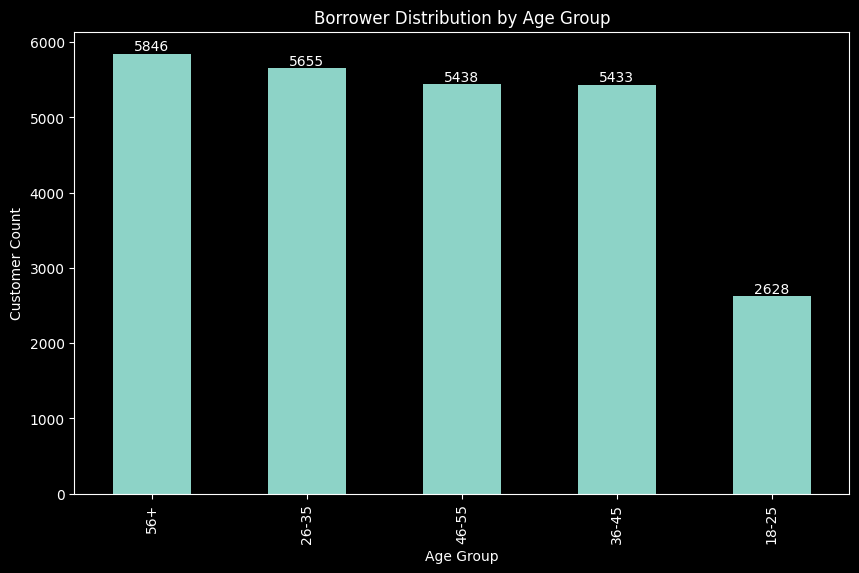

In [ ]:
# Age Group Distribution

age_counts = df['age_group'].value_counts()

plt.figure(figsize= (10,6))

ax= age_counts.plot(
    kind= 'bar'
)

plt.title('Borrower Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Customer Count')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

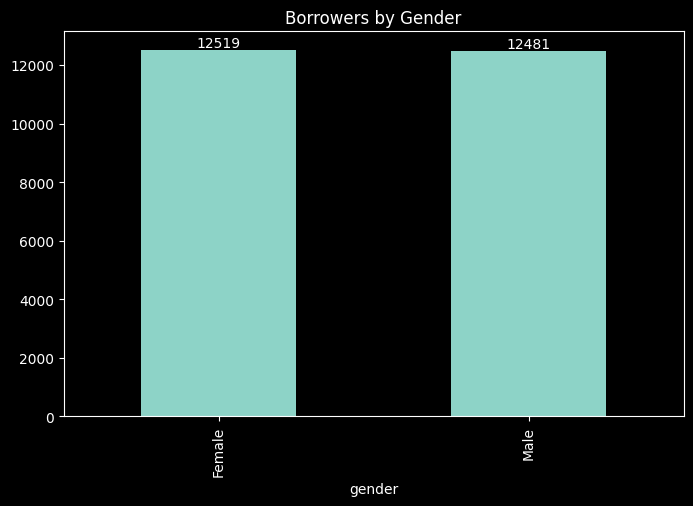

In [ ]:
# Gender Distribution

gender_counts = df['gender'].value_counts()

plt.figure(figsize=(8,5))

ax = gender_counts.plot(
    kind= 'bar'
)

plt.title('Borrowers by Gender')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

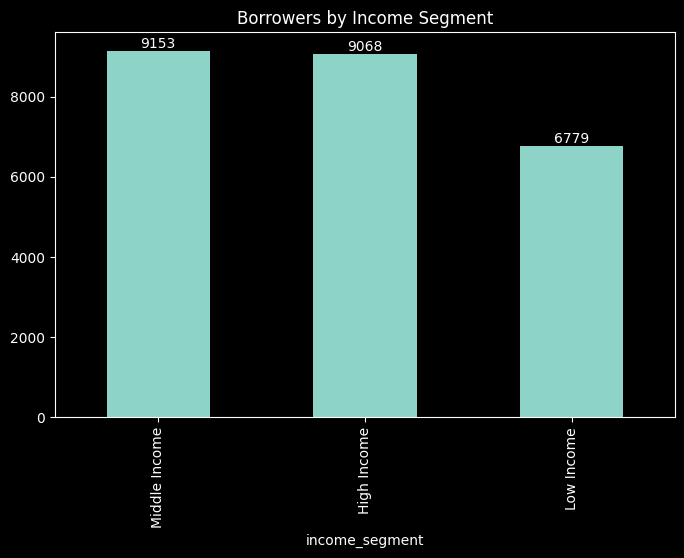

In [ ]:
# Income Segment Distribution

income_counts = df['income_segment'].value_counts()

plt.figure(figsize=(8,5))

ax = income_counts.plot(
    kind= 'bar'
)

plt.title('Borrowers by Income Segment')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Q2 Which Age Groups Take Most Loans?

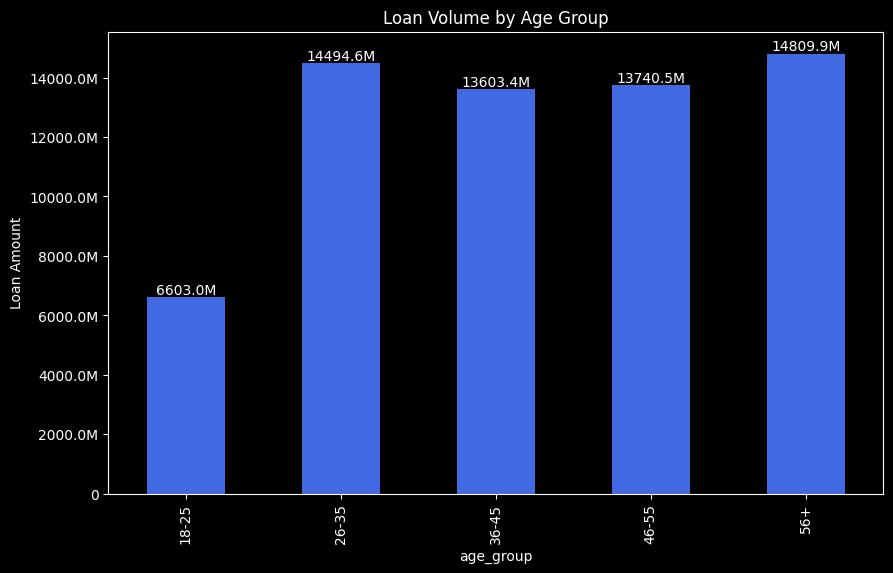

In [ ]:

age_loan = df.groupby(
    'age_group'
)['loan_amount'].sum()

plt.figure(figsize=(10,6))

ax = age_loan.plot(
    kind='bar',
    color= 'royalblue'
)

ax.yaxis.set_major_formatter(
    FuncFormatter(millions)
)

plt.title('Loan Volume by Age Group')
plt.ylabel('Loan Amount')

for container in ax.containers:

    labels = [
        format_label(v)
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels
    )

plt.show()

### Q3 Which Income Segments Generate Highest Loan Volume?

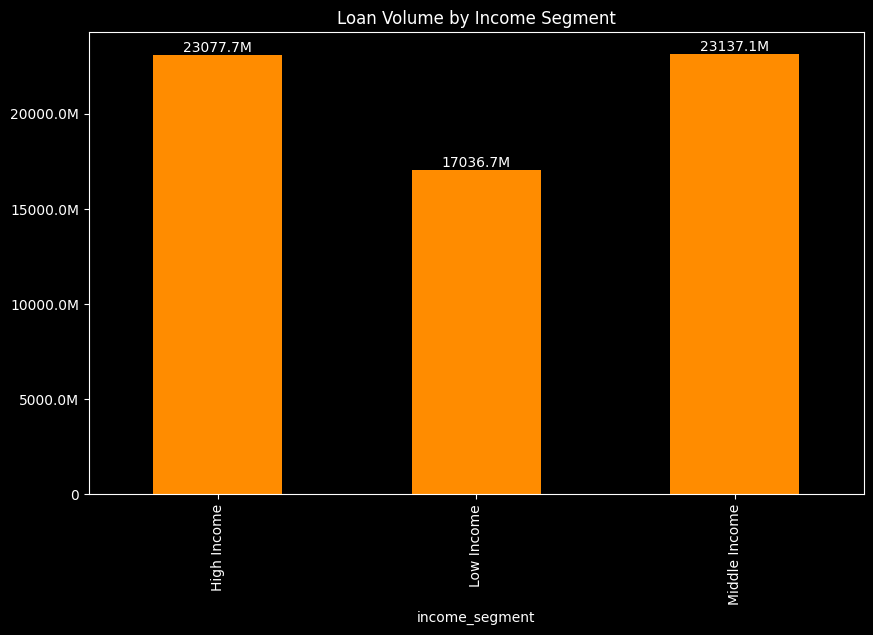

In [ ]:
income_loan = df.groupby(
    'income_segment'
)['loan_amount'].sum()

plt.figure(figsize=(10,6))

ax = income_loan.plot(
    kind= 'bar',
    color= 'darkorange'
)

ax.yaxis.set_major_formatter(
    FuncFormatter(millions)
)

plt.title('Loan Volume by Income Segment')

for container in ax.containers:

    labels = [
        format_label(v)
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels
    )

plt.show()

### Q4 Do Certain Occupations Show Higher Risk?

<function matplotlib.pyplot.show(close=None, block=None)>

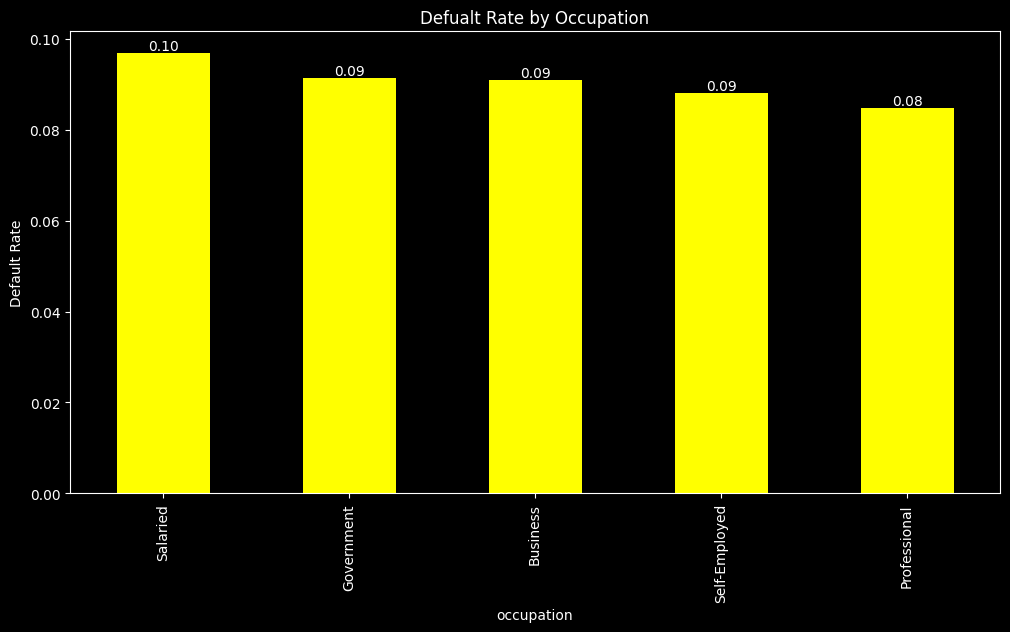

In [ ]:
occ_risk = df.groupby(
    'occupation'
)['loan_default'].mean().sort_values(
    ascending= False
)

plt.figure (figsize=(12,6))

ax = occ_risk.plot(
    kind= 'bar',
    color= 'yellow'
)

plt.title('Defualt Rate by Occupation')
plt.ylabel('Default Rate')

for container in ax.containers:
    ax.bar_label(
        container,fmt= '%.2f'
    )

plt.show

### Q5 Overall Default Rate

In [ ]:
default_rate = df['loan_default'].mean() * 100

print(f"Overall Default Rate: {default_rate:.2f}%")

Overall Default Rate: 9.05%


### Q6 Default Rate by Risk Category

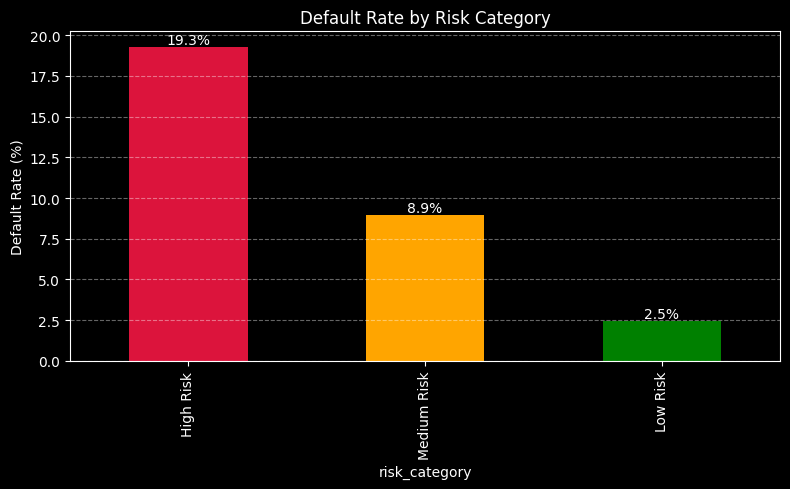

In [ ]:
risk_default = (
    df.groupby('risk_category')['loan_default'].mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

ax = risk_default.plot(
    kind = 'bar',
    color = ['crimson','orange','green']
)

plt.title('Default Rate by Risk Category')
plt.ylabel('Default Rate (%)')

for container in ax.containers:
    ax.bar_label(container, fmt= '%.1f%%')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Q7 Debt-to-Income Ratio vs Default

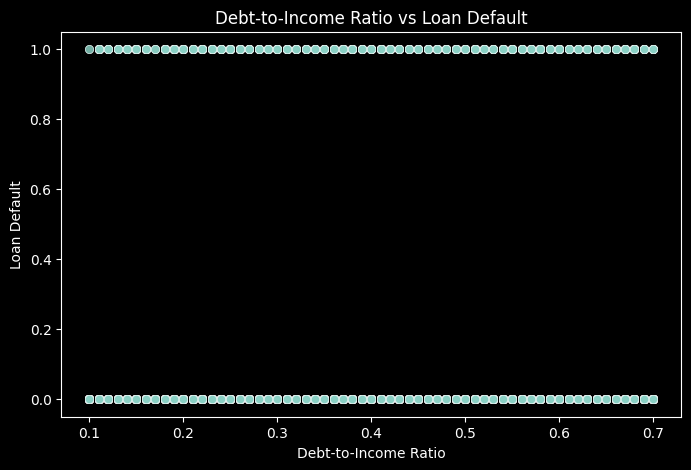

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='debt_to_income_ratio',
    y='loan_default',
    alpha=0.3
)

plt.title('Debt-to-Income Ratio vs Loan Default')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Loan Default')

plt.show()

### Q8 Risk Category Composition

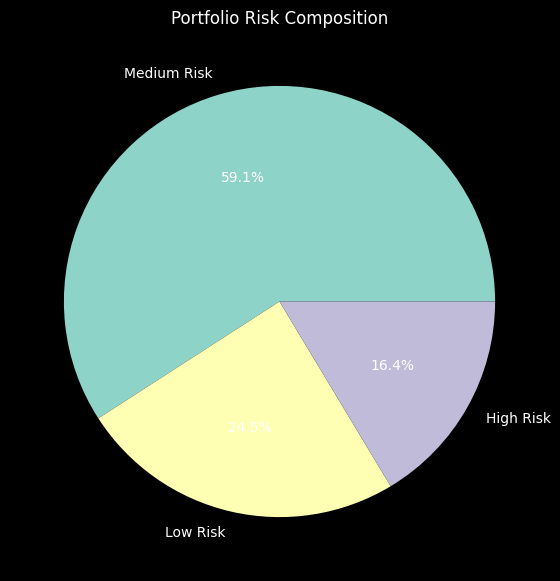

In [ ]:
risk_counts = df['risk_category'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%'
)

plt.title('Portfolio Risk Composition')

plt.show()

### Q9 Loan Products Generating Highest Volume

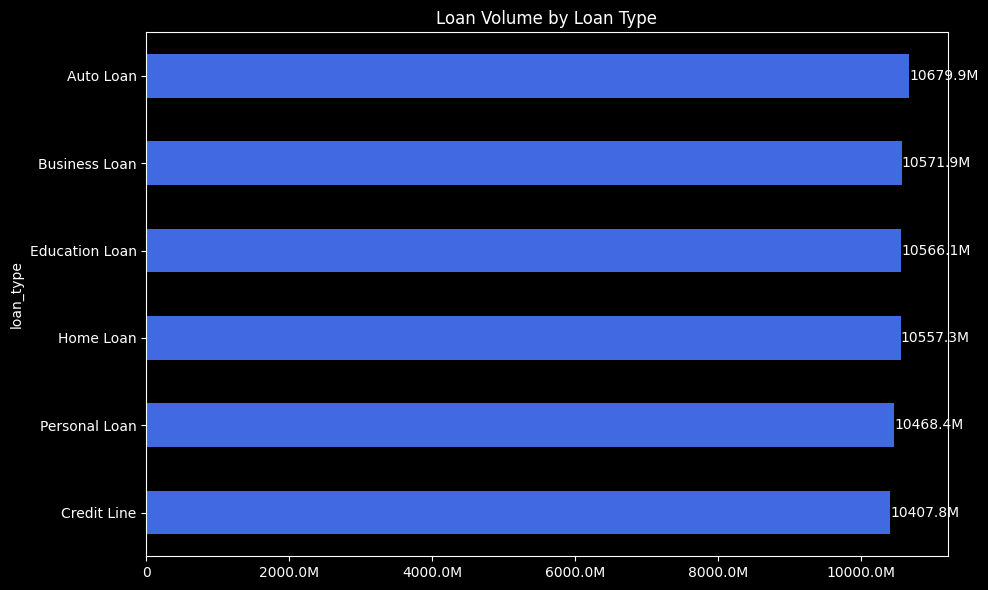

In [ ]:
loan_volume = (
    df.groupby('loan_type')['loan_amount']
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10,6))

ax = loan_volume.plot(
    kind='barh',
    color='royalblue'
)

ax.xaxis.set_major_formatter(
    FuncFormatter(millions)
)

for container in ax.containers:

    labels = [
        format_label(v)
        for v in container.datavalues
    ]

    ax.bar_label(
        container,
        labels=labels
    )

plt.title('Loan Volume by Loan Type')

plt.tight_layout()
plt.show()

### Q10 Highest Default Rate by Loan Type

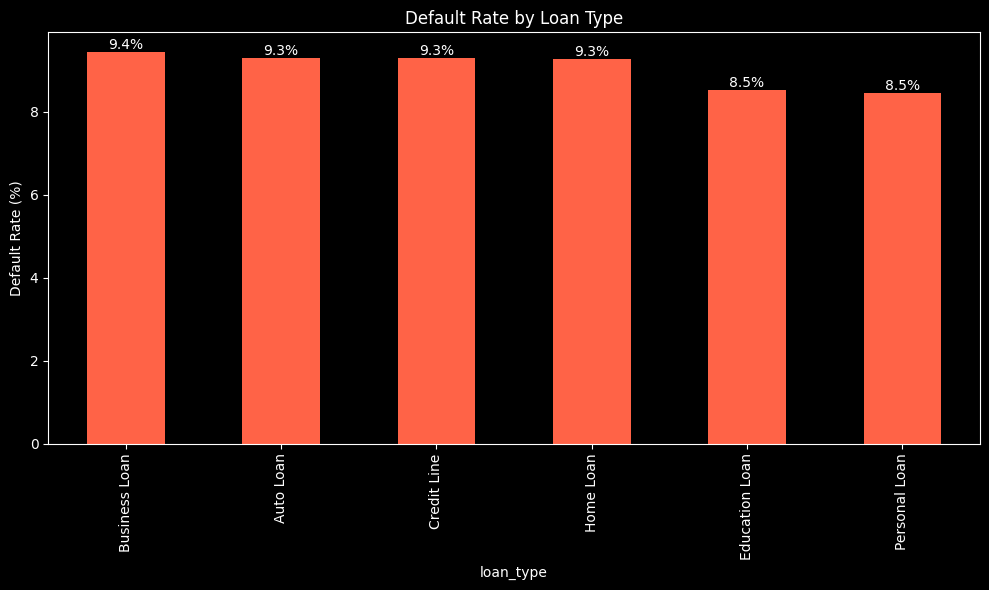

In [ ]:
loan_default_rate = (
    df.groupby('loan_type')['loan_default']
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,6))

ax = loan_default_rate.plot(
    kind='bar',
    color='tomato'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Default Rate by Loan Type')
plt.ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

### Q11 Loan Status Distribution

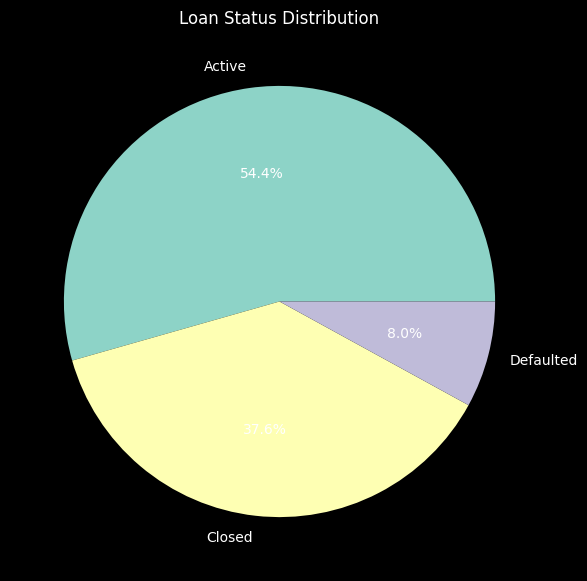

In [ ]:
status_counts = df['loan_status'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title('Loan Status Distribution')

plt.show()

### Q12 Loan Issuance Trend

In [ ]:
df['loan_issue_date'] = pd.to_datetime(
    df['loan_issue_date']
)

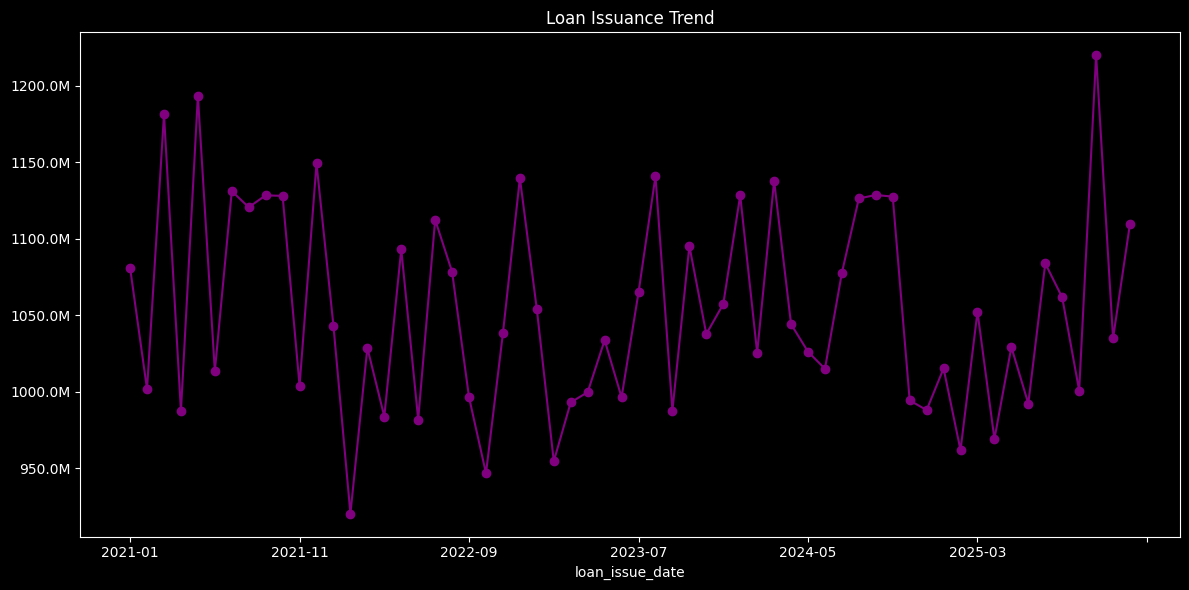

In [ ]:
monthly_loans = (
    df.groupby(
        df['loan_issue_date'].dt.to_period('M')
    )['loan_amount']
     .sum()
)

monthly_loans.index = monthly_loans.index.astype(str)

plt.figure(figsize=(12,6))

monthly_loans.plot(
    kind='line',
    marker='o',
    color='purple'
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(millions)
)

plt.title('Loan Issuance Trend')

plt.tight_layout()
plt.show()

### Q13 States with Highest Loan Amounts

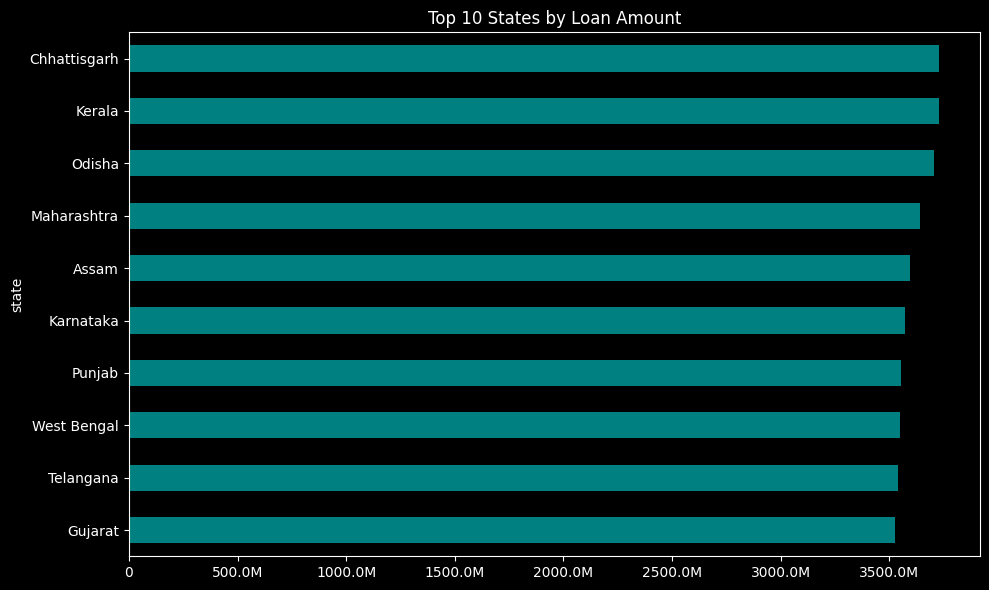

In [ ]:
state_loans = (
    df.groupby('state')['loan_amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

ax = state_loans.sort_values().plot(
    kind='barh',
    color='teal'
)

ax.xaxis.set_major_formatter(
    FuncFormatter(millions)
)

plt.title('Top 10 States by Loan Amount')

plt.tight_layout()
plt.show()

### Q14 States with Highest Default Rates

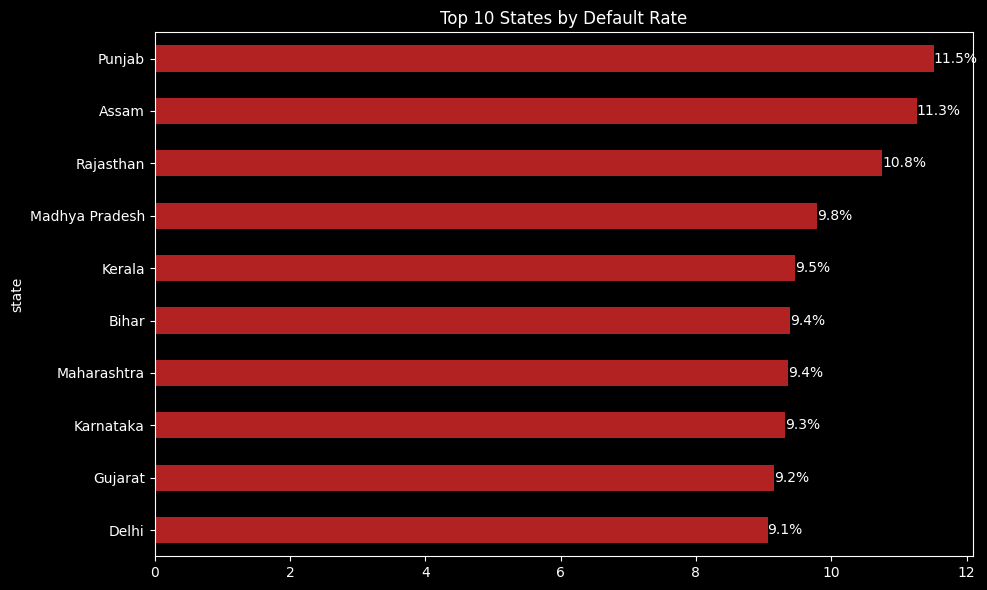

In [ ]:
state_default = (
    df.groupby('state')['loan_default']
      .mean()
      .sort_values(ascending=False)
      .head(10) * 100
)

plt.figure(figsize=(10,6))

ax = state_default.sort_values().plot(
    kind='barh',
    color='firebrick'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Top 10 States by Default Rate')

plt.tight_layout()
plt.show()

### Q15 Cities Contributing Most Revenue & Risk

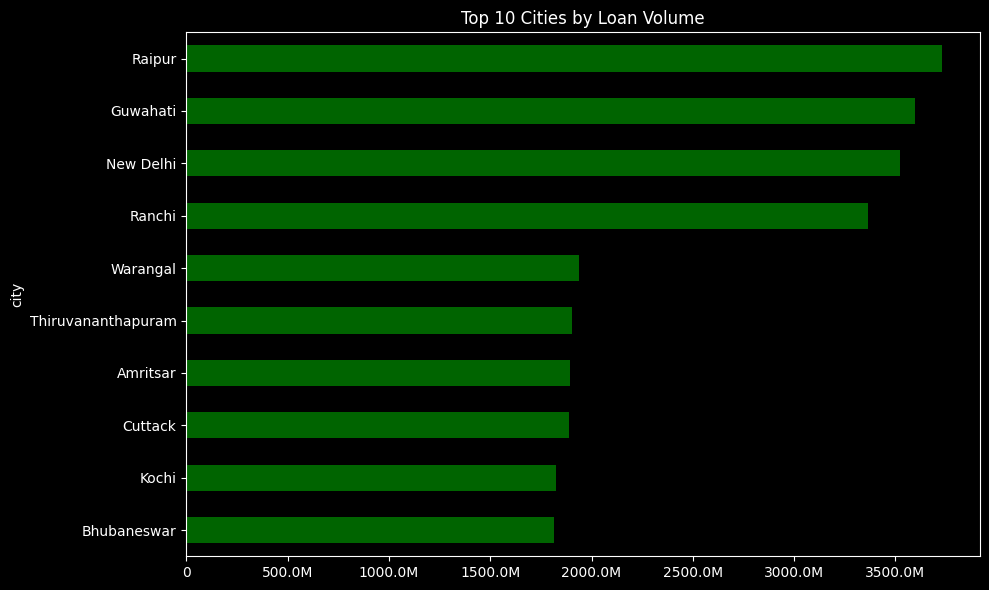

In [ ]:
# Revenue

city_revenue = (
    df.groupby('city')['loan_amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

ax = city_revenue.sort_values().plot(
    kind='barh',
    color='darkgreen'
)

ax.xaxis.set_major_formatter(
    FuncFormatter(millions)
)

plt.title('Top 10 Cities by Loan Volume')

plt.tight_layout()
plt.show()

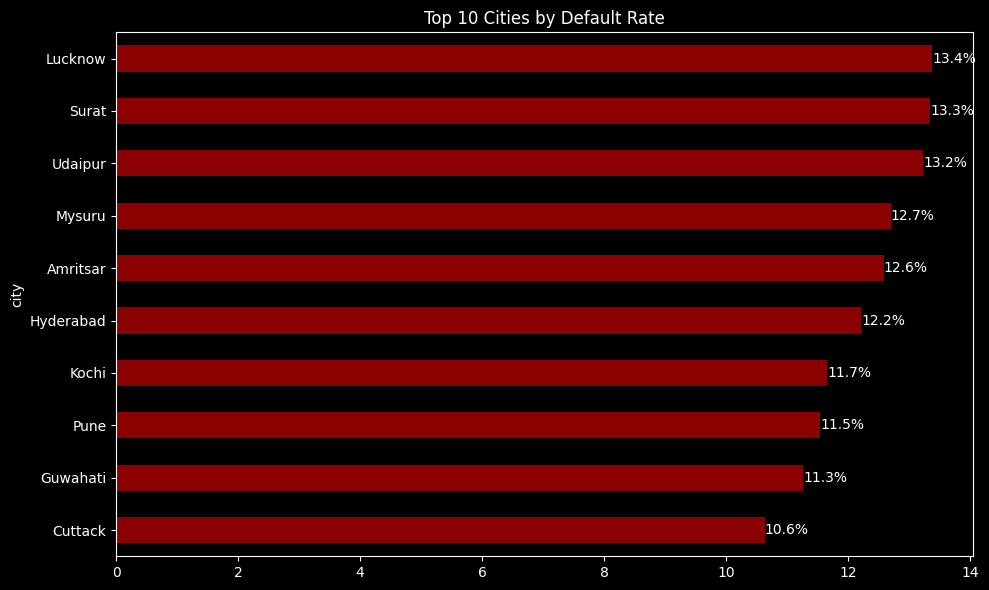

In [ ]:
# Risk

city_risk = (
    df.groupby('city')['loan_default']
      .mean()
      .sort_values(ascending=False)
      .head(10) * 100
)

plt.figure(figsize=(10,6))

ax = city_risk.sort_values().plot(
    kind='barh',
    color='darkred'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title('Top 10 Cities by Default Rate')

plt.tight_layout()
plt.show()